<a href="https://colab.research.google.com/github/AHMEDVALL70/ahmed-vall-cv/blob/main/Procurement_Fraud_Detection_11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🛂 Project 11: Public Procurement Fraud Detection System

**Author:** Ahmed Vall Jemal Dine Sidina | AHMEDVALL70

**Context:** Rooted in 20+ years of direct experience in public procurement — as Procurement Officer and Committee Member at ANRPTS and the HIV/AIDS Control Project, this model addresses real anomalies encountered in government tendering processes.

**Goal:** Develop an AI system that detects anomalies and suspicious contracts in government procurement data using unsupervised machine learning.

**Algorithm:** Isolation Forest · Anomaly Detection · Unsupervised Learning

**Use Cases:** Government audit support · Contract fraud prevention · Public finance integrity

Libraries loaded successfully!
Public Procurement Fraud Detection System
Author: Ahmed Vall Jemal Dine Sidina | AHMEDVALL70

Total contracts loaded: 15

AI Model trained successfully!

        DETECTION SUMMARY REPORT
  Total Contracts Analyzed : 15
  [OK] Normal Contracts    : 12
  [!!] Suspicious Contracts: 3
  Fraud Detection Rate     : 20.0%

[ALL CONTRACTS ANALYSIS]

Vendor         Amount (USD)   Days  Violations  Risk Score           Status
---------------------------------------------------------------------------
Vendor_A     $      50,000     15           0      0.4064             [OK]
Vendor_B     $      48,000     14           0      0.4730             [OK]
Vendor_C     $      52,000     16           0      0.4839             [OK]
Vendor_D     $     450,000      2           3      0.6308  [!!] SUSPICIOUS
Vendor_E     $      49,000     15           0      0.4031             [OK]
Vendor_F     $      51,000     14           0      0.4423             [OK]
Vendor_G     $      47,

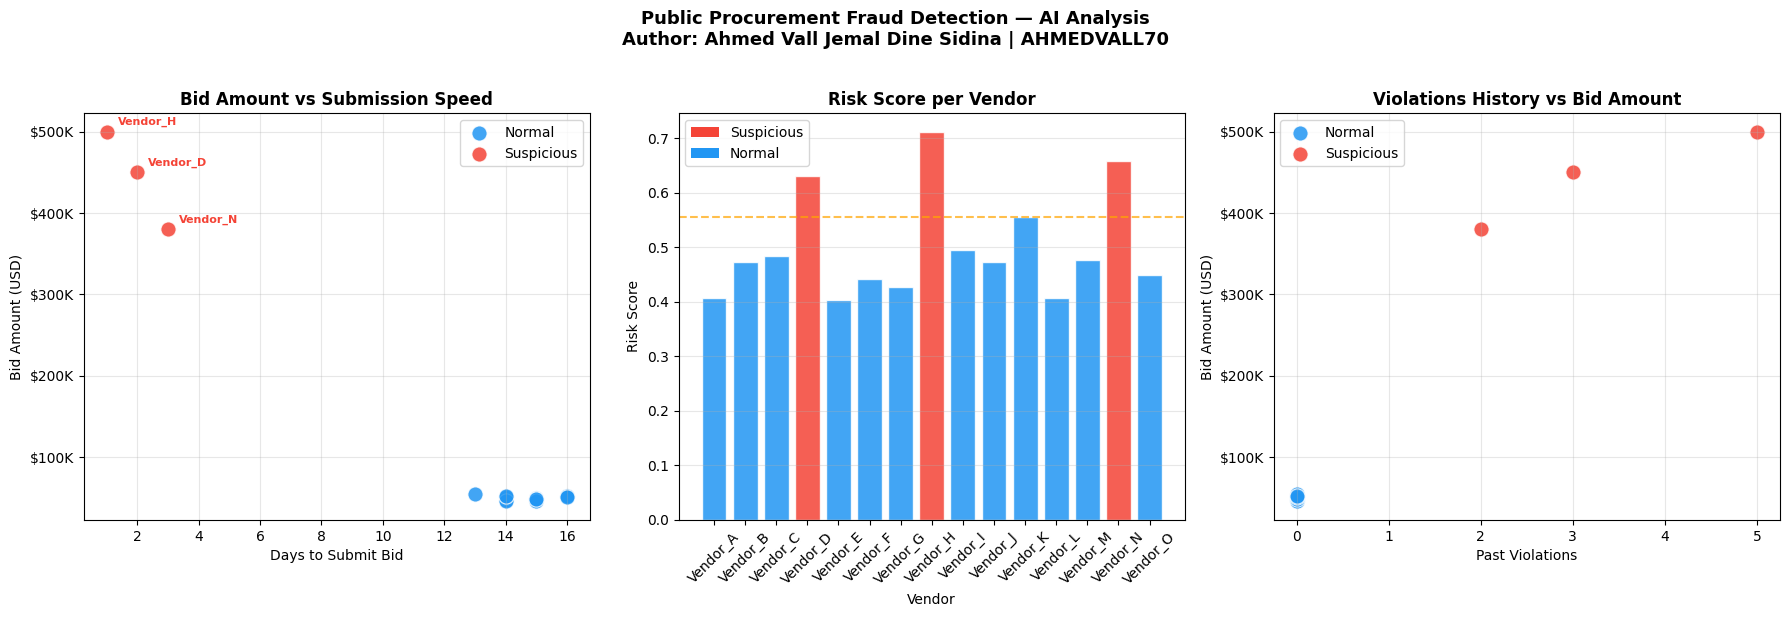


Analysis complete — Charts saved!


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

print("Libraries loaded successfully!")
print("=" * 55)
print("Public Procurement Fraud Detection System")
print("Author: Ahmed Vall Jemal Dine Sidina | AHMEDVALL70")
print("=" * 55)

# ─── بناء البيانات ───
data = {
    'bid_id': range(1, 16),
    'vendor_name': [
        'Vendor_A', 'Vendor_B', 'Vendor_C', 'Vendor_D', 'Vendor_E',
        'Vendor_F', 'Vendor_G', 'Vendor_H', 'Vendor_I', 'Vendor_J',
        'Vendor_K', 'Vendor_L', 'Vendor_M', 'Vendor_N', 'Vendor_O'
    ],
    'bid_amount_usd': [
        50000, 48000, 52000, 450000, 49000,
        51000, 47000, 500000, 53000, 46000,
        55000, 48500, 51500, 380000, 52500
    ],
    'days_to_submit': [
        15, 14, 16,  2, 15,
        14, 15,  1, 16, 14,
        13, 15, 16,  3, 14
    ],
    'past_violations': [
        0, 0, 0, 3, 0,
        0, 0, 5, 0, 0,
        0, 0, 0, 2, 0
    ],
    'num_bids_same_period': [
        3, 4, 3, 1, 3,
        4, 3, 1, 4, 3,
        4, 3, 4, 1, 3
    ]
}

df = pd.DataFrame(data)
print(f"\nTotal contracts loaded: {len(df)}\n")

# ─── تدريب النموذج ───
features = df[['bid_amount_usd', 'days_to_submit', 'past_violations', 'num_bids_same_period']]

scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

model = IsolationForest(contamination=0.2, n_estimators=200, random_state=42)
df['anomaly_score'] = model.fit_predict(features_scaled)
df['risk_score'] = -model.score_samples(features_scaled)
df['status'] = df['anomaly_score'].map({1: 'Normal', -1: 'Suspicious'})

print("AI Model trained successfully!")

# ─── ملخص النتائج ───
normal = df[df['anomaly_score'] == 1]
suspicious = df[df['anomaly_score'] == -1]

print("\n" + "=" * 55)
print("        DETECTION SUMMARY REPORT")
print("=" * 55)
print(f"  Total Contracts Analyzed : {len(df)}")
print(f"  [OK] Normal Contracts    : {len(normal)}")
print(f"  [!!] Suspicious Contracts: {len(suspicious)}")
print(f"  Fraud Detection Rate     : {len(suspicious)/len(df)*100:.1f}%")
print("=" * 55)

print("\n[ALL CONTRACTS ANALYSIS]\n")
print(f"{'Vendor':<12} {'Amount (USD)':>14} {'Days':>6} {'Violations':>11} {'Risk Score':>11} {'Status':>16}")
print("-" * 75)
for _, row in df.iterrows():
    status = "[!!] SUSPICIOUS" if row['anomaly_score'] == -1 else "[OK]"
    print(f"{row['vendor_name']:<12} ${row['bid_amount_usd']:>12,} {row['days_to_submit']:>6} {row['past_violations']:>11} {row['risk_score']:>11.4f} {status:>16}")
print("-" * 75)

# ─── الرسوم البيانية ───
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle(
    'Public Procurement Fraud Detection — AI Analysis\n'
    'Author: Ahmed Vall Jemal Dine Sidina | AHMEDVALL70',
    fontsize=13, fontweight='bold', y=1.02
)

colors = {'Normal': '#2196F3', 'Suspicious': '#F44336'}

# Chart 1: Bid Amount vs Days to Submit
ax1 = axes[0]
for status, group in df.groupby('status'):
    ax1.scatter(group['days_to_submit'], group['bid_amount_usd'],
                label=status, color=colors[status], s=120, alpha=0.85,
                edgecolors='white', linewidth=0.8)
for _, row in suspicious.iterrows():
    ax1.annotate(row['vendor_name'],
                 (row['days_to_submit'], row['bid_amount_usd']),
                 textcoords="offset points", xytext=(8, 5),
                 fontsize=8, color='#F44336', fontweight='bold')
ax1.set_title('Bid Amount vs Submission Speed', fontweight='bold')
ax1.set_xlabel('Days to Submit Bid')
ax1.set_ylabel('Bid Amount (USD)')
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
ax1.legend()
ax1.grid(True, alpha=0.3)

# Chart 2: Risk Score per Vendor
ax2 = axes[1]
bar_colors = ['#F44336' if s == 'Suspicious' else '#2196F3' for s in df['status']]
ax2.bar(df['vendor_name'], df['risk_score'], color=bar_colors, alpha=0.85, edgecolor='white')
ax2.set_title('Risk Score per Vendor', fontweight='bold')
ax2.set_xlabel('Vendor')
ax2.set_ylabel('Risk Score')
ax2.tick_params(axis='x', rotation=45)
ax2.grid(True, alpha=0.3, axis='y')
ax2.axhline(y=df[df['status']=='Normal']['risk_score'].max(),
            color='orange', linestyle='--', alpha=0.7, label='Normal threshold')
from matplotlib.patches import Patch
ax2.legend(handles=[Patch(facecolor='#F44336', label='Suspicious'),
                    Patch(facecolor='#2196F3', label='Normal')])

# Chart 3: Violations vs Bid Amount
ax3 = axes[2]
for status, group in df.groupby('status'):
    ax3.scatter(group['past_violations'], group['bid_amount_usd'],
                label=status, color=colors[status], s=120, alpha=0.85,
                edgecolors='white', linewidth=0.8)
ax3.set_title('Violations History vs Bid Amount', fontweight='bold')
ax3.set_xlabel('Past Violations')
ax3.set_ylabel('Bid Amount (USD)')
ax3.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
ax3.legend()
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('procurement_fraud_detection.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nAnalysis complete — Charts saved!")
